In [1]:
from pathlib import Path
from PIL import Image
from collections import Counter

DATA_DIR = Path("../data")

images = (
    list(DATA_DIR.rglob("*.jpg")) +
    list(DATA_DIR.rglob("*.jpeg")) +
    list(DATA_DIR.rglob("*.png"))
)

print("Total images:", len(images))

sizes = Counter()

for img_path in images:
    try:
        with Image.open(img_path) as img:
            sizes[img.size] += 1
    except:
        print("Bad image:", img_path)

print("\nImage sizes:")
for size, count in sizes.most_common(10):
    print(size, ":", count)

print("\nTrain Images:")
print("Real images:", len(list((DATA_DIR / "train/REAL").glob("*"))))
print("Fake images:", len(list((DATA_DIR / "train/FAKE").glob("*"))))

print("\nTest Images:")
print("Real images:", len(list((DATA_DIR / "test/REAL").glob("*"))))
print("Fake images:", len(list((DATA_DIR / "test/FAKE").glob("*"))))

Total images: 120000

Image sizes:
(32, 32) : 120000

Train Images:
Real images: 50000
Fake images: 50000

Test Images:
Real images: 10000
Fake images: 10000


In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    "../data/train",
    transform=train_transform
)

print("Total:", len(dataset))
print("Classes:", dataset.class_to_idx)

Total: 100000
Classes: {'FAKE': 0, 'REAL': 1}


In [4]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))

Training: 80000
Validation: 20000


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 1250
Validation batches: 313


In [6]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([64, 3, 224, 224])
Labels: torch.Size([64])


In [7]:
import torch.nn as nn
from torchvision import models

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(weights="DEFAULT")

model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [8]:
num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(num_features, 2)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [12]:
# Choose device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

Using device: mps


In [10]:
num_epochs = 3

for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total


    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_total


    # =========================
    # PRINT RESULTS
    # =========================
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/3] Train Loss: 0.1301 Train Acc: 0.9485 Val Loss: 0.0650 Val Acc: 0.9764
Epoch [2/3] Train Loss: 0.0564 Train Acc: 0.9787 Val Loss: 0.0547 Val Acc: 0.9804
Epoch [3/3] Train Loss: 0.0341 Train Acc: 0.9875 Val Loss: 0.0594 Val Acc: 0.9787


In [15]:
# Saving model weights
torch.save(model.state_dict(), "../model/efficientnet_b0.pth")

In [24]:
# Checking test set

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

test_dataset = datasets.ImageFolder(
    "../data/test",
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Test images:", len(test_dataset))
print("Classes:", test_dataset.classes)
print("Class mapping:", test_dataset.class_to_idx)

Test images: 20000
Classes: ['FAKE', 'REAL']
Class mapping: {'FAKE': 0, 'REAL': 1}


In [25]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt


# Put model in evaluation mode
model.eval()

all_labels = []
all_fake_probs = []
all_preds = []


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        # Probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # IMPORTANT:
        # fake = class 0
        fake_probs = probabilities[:, 0]

        # Predicted class
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.numpy())
        all_fake_probs.extend(fake_probs.cpu().numpy())
        all_preds.extend(predictions.cpu().numpy())


# Convert to numpy arrays
all_labels = np.array(all_labels)
all_fake_probs = np.array(all_fake_probs)
all_preds = np.array(all_preds)


# ------------------------------------------------
# Metrics
# ------------------------------------------------

accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels,
    all_preds,
    average="macro"
)

recall = recall_score(
    all_labels,
    all_preds,
    average="macro"
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)


# For ROC-AUC we want:
# AI-generated = positive class
# Therefore convert:
# fake (0) -> 1
# real (1) -> 0

fake_labels = (all_labels == 0).astype(int)

roc_auc = roc_auc_score(
    fake_labels,
    all_fake_probs
)

average_precision = average_precision_score(
    fake_labels,
    all_fake_probs
)


# ------------------------------------------------
# Print results
# ------------------------------------------------

print("=" * 50)
print("TEST SET RESULTS")
print("=" * 50)

print(f"Accuracy          : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Macro Precision   : {precision:.4f}")
print(f"Macro Recall      : {recall:.4f}")
print(f"Macro F1          : {f1:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")
print(f"Average Precision : {average_precision:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["AI-generated", "Real"]
    )
)

TEST SET RESULTS
Accuracy          : 0.9807 (98.07%)
Macro Precision   : 0.9807
Macro Recall      : 0.9807
Macro F1          : 0.9807
ROC-AUC           : 0.9981
Average Precision : 0.9981

Classification Report:
              precision    recall  f1-score   support

AI-generated       0.98      0.98      0.98     10000
        Real       0.98      0.98      0.98     10000

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000



In [38]:
from pathlib import Path

IMAGES_PATH = Path("../images") 
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=100):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Confusion Matrix:
[[9789  211]
 [ 175 9825]]


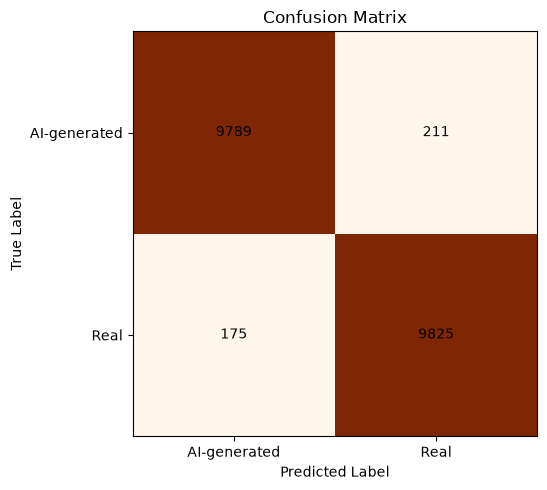

In [42]:
cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm, cmap="Oranges")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["AI-generated", "Real"])
plt.yticks([0, 1], ["AI-generated", "Real"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

# plt.colorbar()
plt.tight_layout()
save_fig("confusion_matrix")
plt.show()

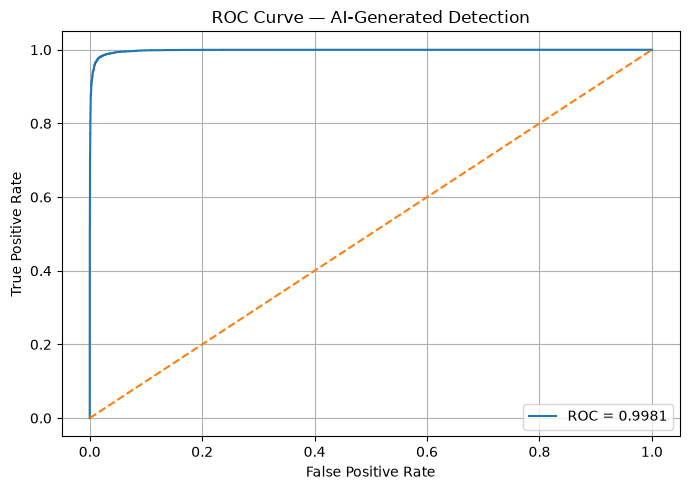

In [44]:
fpr, tpr, thresholds = roc_curve(
    fake_labels,
    all_fake_probs
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — AI-Generated Detection")

plt.legend()
plt.grid()

save_fig("roc_curve")
plt.show()

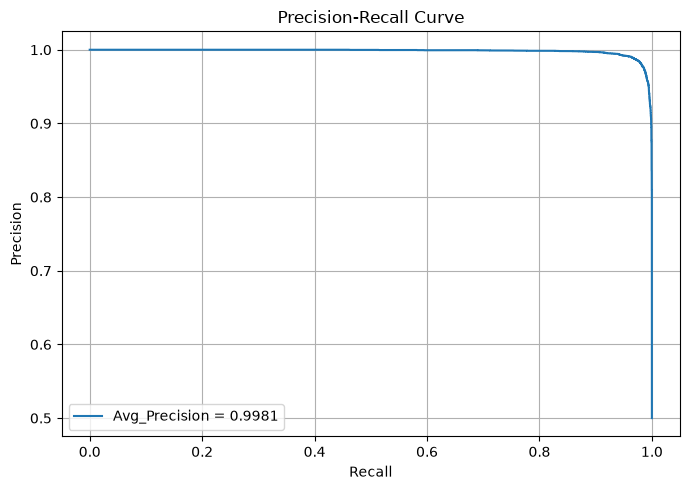

In [45]:
precision_values, recall_values, thresholds_pr = precision_recall_curve(
    fake_labels,
    all_fake_probs
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values,
    label=f"Avg_Precision = {average_precision:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()
plt.grid()

save_fig("precision_recall_curve")
plt.show()